In [1]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path

In [27]:
data_path = Path("/Users/jininaljayyousi/mindclick/data/raw/B_01_SE001_CB_Train06.edf")
flash_table_path = Path("/Users/jininaljayyousi/mindclick/data/processed/flash_table.csv")

raw = mne.io.read_raw_edf(data_path, preload=True)
flash_table = pd.read_csv(flash_table_path)
raw.set_channel_types({"StimulusBegin": "stim"})

print(raw)
print(flash_table.head())

Extracting EDF parameters from /Users/jininaljayyousi/mindclick/data/raw/B_01_SE001_CB_Train06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 40455  =      0.000 ...   158.027 secs...
<RawEDF | B_01_SE001_CB_Train06.edf, 62 x 40456 (158.0 s), ~19.2 MiB, data loaded>
   flash_index  sample_index  stimulus_code  stimulus_type  current_target  \
0            0          1672            159              0              20   
1            1          1736            155              0              20   
2            2          1800            158              0              20   
3            3          1864            157              0              20   
4            4          1928            156              0              20   

   selected_target  selected_row  selected_column  phase  \
0                0             0                0      2   
1                0             0                0      2   
2                0             0             

/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_44397/3816276722.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_path, preload=True)
/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_44397/3816276722.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(data_path, preload=True)


In [23]:
stimulus_channels = ["StimulusBegin", "StimulusType", "CurrentTarget"]
raw_epochs = raw.copy()
raw_epochs.set_channel_types({"StimulusBegin": "stim"})
events = mne.find_events(raw_epochs, stim_channel="StimulusBegin")
print(events[:10])

Finding events on: StimulusBegin
540 events found on stim channel StimulusBegin
Event IDs: [1]
[[1672    0    1]
 [1736    0    1]
 [1800    0    1]
 [1864    0    1]
 [1928    0    1]
 [1992    0    1]
 [2056    0    1]
 [2120    0    1]
 [2184    0    1]
 [2248    0    1]]


In [24]:
event_sample_indices = events[:, 0]
print("Number of stimulus events:", len(event_sample_indices))
print("Number of flash table rows:", len(flash_table))

Number of stimulus events: 540
Number of flash table rows: 540


In [28]:
eeg_channel_names = [
    name for name in raw.ch_names
    if name.startswith("EEG_")
]

In [29]:
picks = mne.pick_channels(raw.ch_names, include=eeg_channel_names)

epochs = mne.Epochs(
    raw,
    events=events,
    event_id=1,
    tmin=0.0,
    tmax=0.8,
    picks=picks,
    preload=True,
    baseline=None,
    detrend=1,
)

print(epochs)

Not setting metadata
540 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 540 events and 206 original time points ...


/Users/jininaljayyousi/mindclick/venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:3629: RuntimeWarning: divide by zero encountered in matmul
  newdata[sl] = newdata[sl] - A @ coef
/Users/jininaljayyousi/mindclick/venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:3629: RuntimeWarning: overflow encountered in matmul
  newdata[sl] = newdata[sl] - A @ coef
/Users/jininaljayyousi/mindclick/venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:3629: RuntimeWarning: invalid value encountered in matmul
  newdata[sl] = newdata[sl] - A @ coef


0 bad epochs dropped
<Epochs | 540 events (all good), 0 – 0.801 s (baseline off), ~13.6 MiB, data loaded,
 '1': 540>


In [30]:
labels = flash_table["stimulus_type"].to_numpy()
print("Label shape:", labels.shape)
print("Unique labels:", np.unique(labels))

Label shape: (540,)
Unique labels: [0 1]


In [31]:
target_indices = np.where(labels == 1)[0]
non_target_indices = np.where(labels == 0)[0]

print("Target epochs:", len(target_indices))
print("Non-target epochs:", len(non_target_indices))

Target epochs: 60
Non-target epochs: 480


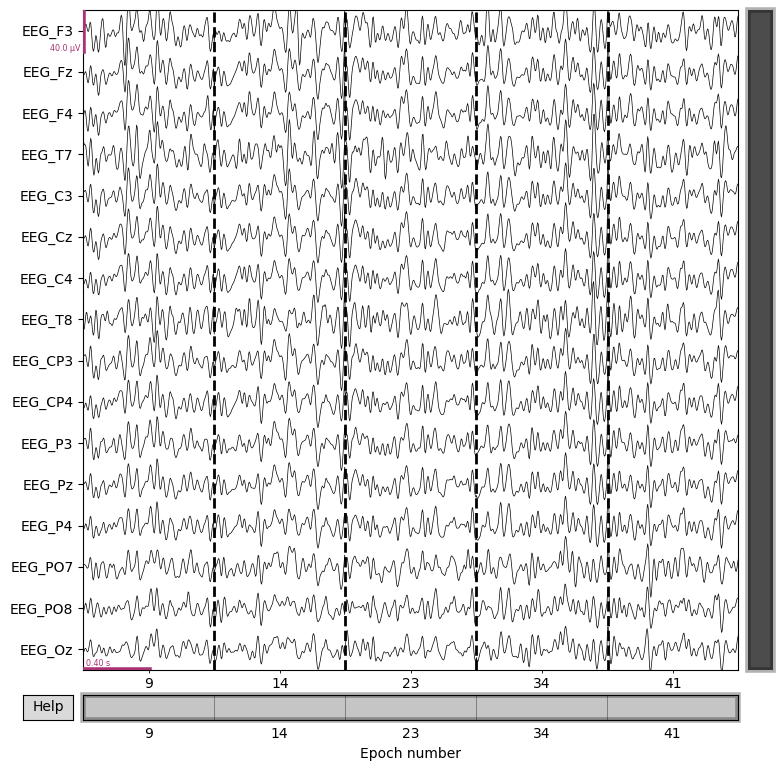

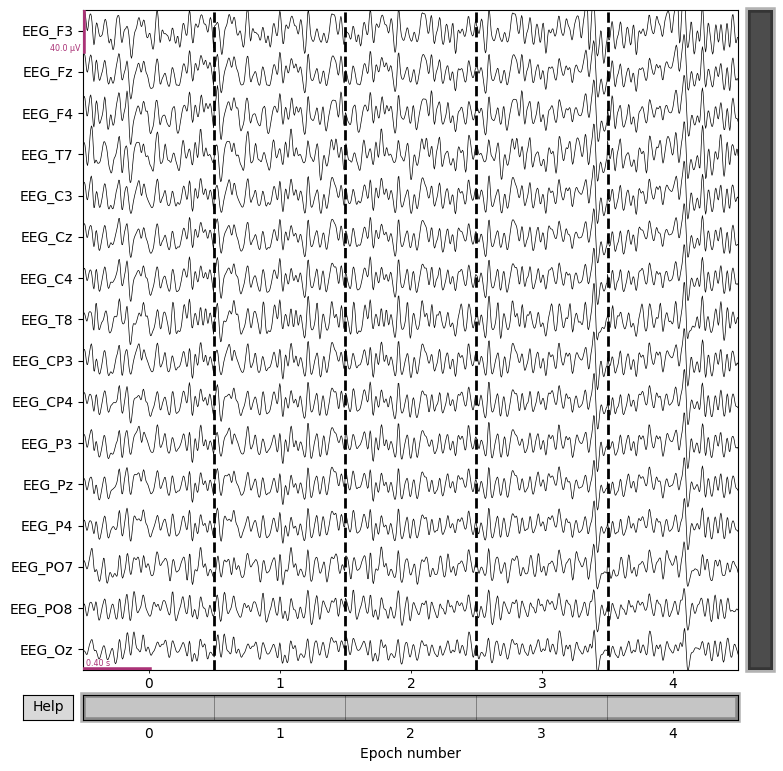

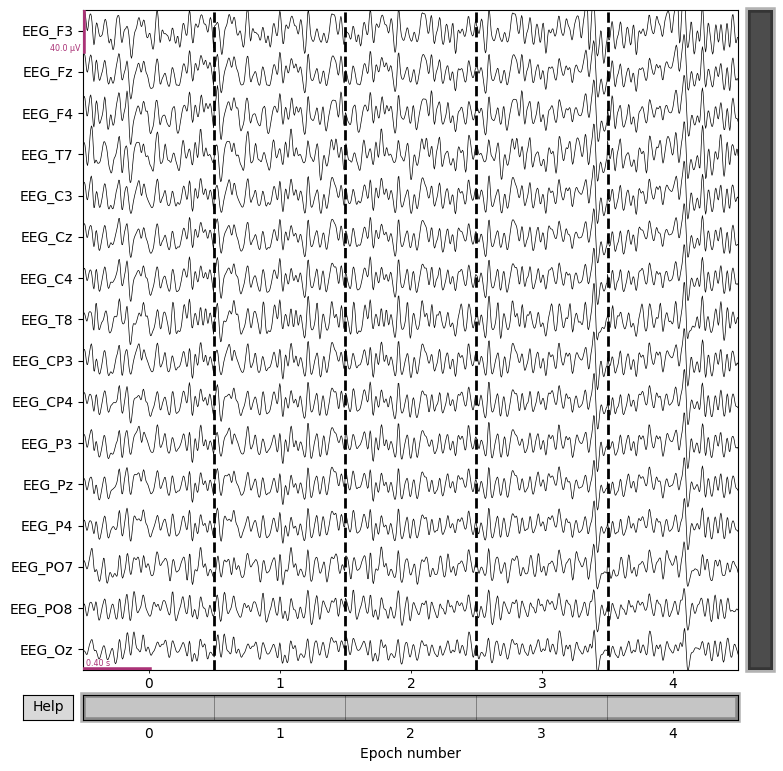

In [33]:
epochs[target_indices[:5]].plot()
epochs[non_target_indices[:5]].plot()

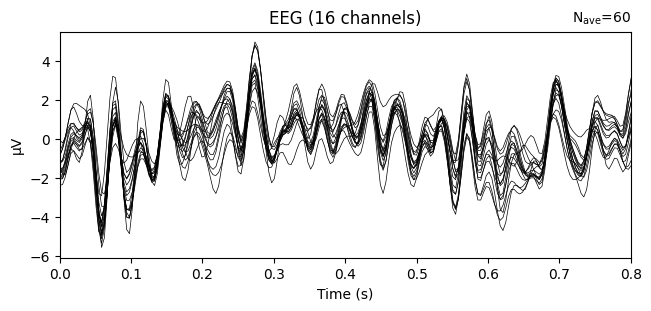

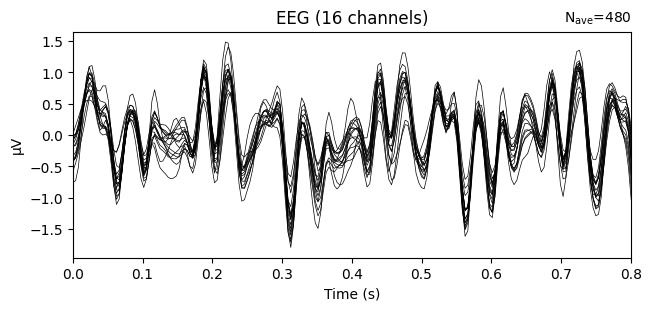

Text(0.5, 0.98, 'Non-Target Response')

In [36]:
target_evoked = epochs[target_indices].average()
non_target_evoked = epochs[non_target_indices].average()

target_figure = target_evoked.plot()
target_figure.suptitle("Target Response")

non_target_figure = non_target_evoked.plot()
non_target_figure.suptitle("Non-Target Response")

In [37]:
raw.filter(l_freq=0.1, h_freq=30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 8449 samples (33.004 s)



<RawEDF | B_01_SE001_CB_Train06.edf, 62 x 40456 (158.0 s), ~19.2 MiB, data loaded>

In [38]:
epochs = mne.Epochs(
    raw,
    events=events,
    event_id=1,
    tmin=-0.2,
    tmax=0.8,
    picks=picks,
    preload=True,
    baseline=(None, 0),
)

Not setting metadata
540 matching events found
Setting baseline interval to [-0.19921868696855843, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 540 events and 257 original time points ...
0 bad epochs dropped


Need more than one channel to make topography for eeg. Disabling interactivity.


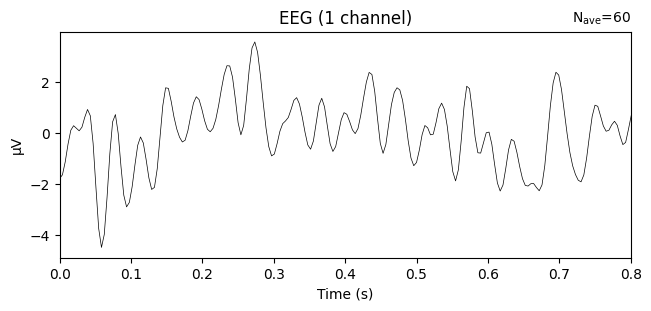

Need more than one channel to make topography for eeg. Disabling interactivity.


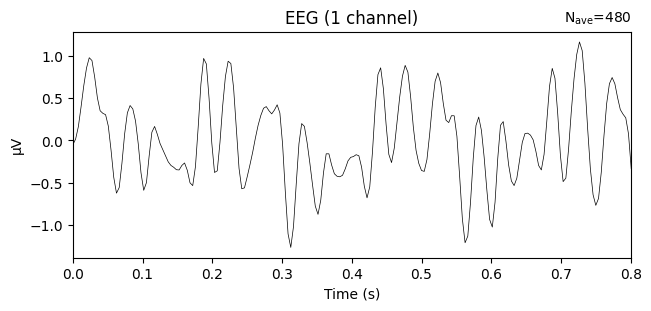

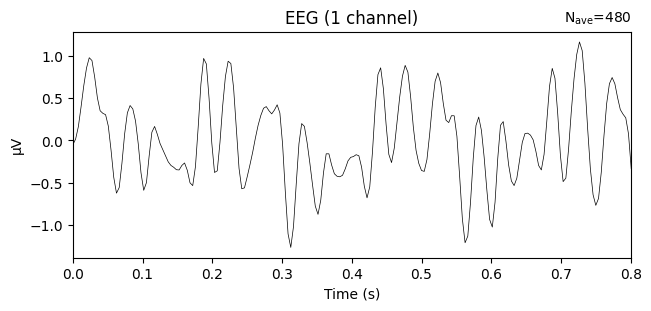

In [39]:
target_evoked.plot(picks=["EEG_Pz"])
non_target_evoked.plot(picks=["EEG_Pz"])

In [40]:
processed_directory = Path("/Users/jininaljayyousi/mindclick/data/processed/")
processed_directory.mkdir(parents=True, exist_ok=True)

epochs.save(processed_directory / "p300_epochs.fif", overwrite=True)

np.save(processed_directory / "p300_labels.npy", labels)

np.save(processed_directory / "p300_event_samples.npy", event_sample_indices)

print("Saved:")
print("p300_epochs.fif")
print("p300_labels.npy")
print("p300_event_samples.npy")

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved:
p300_epochs.fif
p300_labels.npy
p300_event_samples.npy


/var/folders/1k/m00ckqlx5cn3hklkwvwxq6wc0000gn/T/ipykernel_44397/4094798464.py:4: RuntimeWarning: This filename (/Users/jininaljayyousi/mindclick/data/processed/p300_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs.save(processed_directory / "p300_epochs.fif", overwrite=True)
